# Entrega 2: Ingeniería de Características
### Detección de Tráfico Malicioso en Redes IoT
**Santiago Vieira Ceballos — Sara Franco Taborda — Sara Medina Molina**

## 1. Carga y comprensión de los datos

El dataset utilizado es el *Network IoT Dataset* (NICA), disponible en Kaggle,
el cual contiene registros de flujos de red con características extraídas de
múltiples capas y protocolos (DNS, HTTP, SSL), etiquetados como tráfico normal
o como alguno de los tipos de ciberataques presentes en el conjunto.

A continuación se carga el archivo CSV desde el directorio de datos del proyecto.
Los espacios en blanco se tratan como valores nulos (`na_values=[' ']`) para
garantizar una correcta identificación de datos faltantes desde el inicio.

In [3]:
from pathlib import Path
import pandas as pd
import pandas as pd
import numpy as np

DATA_DIR = Path().resolve().parent / "Data"
data_file = "train_test_network.csv"
data_path = DATA_DIR / data_file

df = pd.read_csv(data_path, na_values=[' '])
df.head()

,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,...,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,192.168.1.37,4444,192.168.1.193,49178,tcp,-,290.371539,101568,2592,OTH,...,0,0,-,-,-,-,-,-,1,backdoor
1,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000102,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
2,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000148,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
3,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000113,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
4,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000130,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor


Se inspecciona el número de variables, registros y el tipo de dato asignado a cada columna.

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211043 entries, 0 to 211042
Data columns (total 44 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   src_ip                  211043 non-null  object 
 1   src_port                211043 non-null  int64  
 2   dst_ip                  211043 non-null  object 
 3   dst_port                211043 non-null  int64  
 4   proto                   211043 non-null  object 
 5   service                 211043 non-null  object 
 6   duration                211043 non-null  float64
 7   src_bytes               211043 non-null  int64  
 8   dst_bytes               211043 non-null  int64  
 9   conn_state              211043 non-null  object 
 10  missed_bytes            211043 non-null  int64  
 11  src_pkts                211043 non-null  int64  
 12  src_ip_bytes            211043 non-null  int64  
 13  dst_pkts                211043 non-null  int64  
 14  dst_ip_bytes        

In [5]:
print(f"Registros: {df.shape[0]}")
print(f"Variables: {df.shape[1]}")
print("\nTipos de datos:")
print(df.dtypes)

Registros: 211043
Variables: 44

Tipos de datos:
src_ip                     object
src_port                    int64
dst_ip                     object
dst_port                    int64
proto                      object
service                    object
duration                  float64
src_bytes                   int64
dst_bytes                   int64
conn_state                 object
missed_bytes                int64
src_pkts                    int64
src_ip_bytes                int64
dst_pkts                    int64
dst_ip_bytes                int64
dns_query                  object
dns_qclass                  int64
dns_qtype                   int64
dns_rcode                   int64
dns_AA                     object
dns_RD                     object
dns_RA                     object
dns_rejected               object
ssl_version                object
ssl_cipher                 object
ssl_resumed                object
ssl_established            object
ssl_subject                object

1.2 Verificación y corrección de tipos de datos

Aunque `df.info()` no reporta valores nulos, algunas columnas numéricas
representan códigos o categorías (puertos, clases DNS, etiquetas), por lo que
se convierten a `object` para reflejar correctamente su naturaleza categórica
y evitar que sean tratadas como variables continuas en el análisis posterior.

In [6]:
df = df.astype({
    'src_port'   : 'object',
    'dst_port'   : 'object',
    'dns_qclass' : 'object',
    'dns_qtype'  : 'object',
    'dns_rcode'  : 'object',
    'label'      : 'object'
})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211043 entries, 0 to 211042
Data columns (total 44 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   src_ip                  211043 non-null  object 
 1   src_port                211043 non-null  object 
 2   dst_ip                  211043 non-null  object 
 3   dst_port                211043 non-null  object 
 4   proto                   211043 non-null  object 
 5   service                 211043 non-null  object 
 6   duration                211043 non-null  float64
 7   src_bytes               211043 non-null  int64  
 8   dst_bytes               211043 non-null  int64  
 9   conn_state              211043 non-null  object 
 10  missed_bytes            211043 non-null  int64  
 11  src_pkts                211043 non-null  int64  
 12  src_ip_bytes            211043 non-null  int64  
 13  dst_pkts                211043 non-null  int64  
 14  dst_ip_bytes        

### Estadísticas descriptivas

Se reportan las estadísticas descriptivas de las variables numéricas y categóricas
para entender la distribución, el rango de valores y la frecuencia de cada variable.

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
duration,211043.0,7.700887,5.641419e+02,0.0,0.0,0.00017,0.054196,9.351693e+04
src_bytes,211043.0,258113.564274,1.709490e+07,0.0,0.0,0.00000,130.000000,3.890855e+09
dst_bytes,211043.0,258804.571575,1.802563e+07,0.0,0.0,0.00000,89.000000,3.913853e+09
missed_bytes,211043.0,34432.344295,5.261621e+06,0.0,0.0,0.00000,0.000000,1.854527e+09
src_pkts,211043.0,9.595220,9.177882e+01,0.0,1.0,1.00000,4.000000,2.462300e+04
src_ip_bytes,211043.0,776.082206,2.229703e+04,0.0,48.0,82.00000,415.000000,6.522626e+06
dst_pkts,211043.0,3.846861,3.307058e+02,0.0,0.0,1.00000,2.000000,1.219420e+05
dst_ip_bytes,211043.0,1584.686628,1.901795e+05,0.0,0.0,40.00000,134.000000,8.639552e+07
http_request_body_len,211043.0,0.065418,9.243405e+00,0.0,0.0,0.00000,0.000000,2.338000e+03
http_response_body_len,211043.0,144.929531,3.047244e+04,0.0,0.0,0.00000,0.000000,1.342438e+07


Las variables numéricas presentan distribuciones muy sesgadas: `src_bytes`,
`dst_bytes`, `missed_bytes` y sus derivados tienen media muy superior a la mediana
(50%), lo que sugiere la presencia de valores atípicos. `duration` y los contadores
de paquetes muestran el mismo comportamiento. Esto indica que la mayoría de estas
variables requerirán transformaciones antes de entrenar el modelo.

In [8]:
df.describe(include='object').T

,count,unique,top,freq
src_ip,211043,51,192.168.1.30,61633
src_port,211043,26628,80,3643
dst_ip,211043,753,192.168.1.190,47795
dst_port,211043,2039,80,70673
proto,211043,3,tcp,168747
service,211043,9,-,132032
conn_state,211043,13,S0,51937
dns_query,211043,726,-,176198
dns_qclass,211043,3,0,176275
dns_qtype,211043,12,0,176275


Las variables categóricas muestran que `proto` tiene solo 3 protocolos únicos
(predomina `tcp`), `conn_state` tiene 13 estados posibles y `service` tiene 9.
Las columnas `src_ip` y `dst_ip` tienen 51 y 753 valores únicos respectivamente,
lo que confirma que son identificadores y no deben entrar en la matriz de características.
La variable objetivo `type` tiene 10 clases, siendo `normal` la más frecuente con
50.000 registros. Las columnas SSL, HTTP y DNS muestran valores `-` dominantes,
lo que indica que la mayoría de los flujos no usan esos protocolos.

### Datos duplicados

Se identifican y eliminan los registros duplicados, ya que filas idénticas
en todas sus columnas no aportan información adicional al modelo y pueden
sesgar el entrenamiento.

In [9]:
print('Número de registros duplicados: ', df.duplicated().sum())
df = df.drop_duplicates()
print('Registros después de eliminar duplicados: ', df.shape[0])

Número de registros duplicados:  20569
Registros después de eliminar duplicados:  190474


Se encontraron 20.569 registros duplicados (9.7% del total), los cuales fueron
eliminados. El dataframe quedó con 190.474 registros.

### Valores nulos

Se verifican los valores nulos en el dataframe. El parámetro `na_values=[' ']`
en la carga inicial garantiza que los espacios en blanco sean reconocidos
como nulos por pandas

In [10]:
df.isnull().sum()

src_ip                    0
src_port                  0
dst_ip                    0
dst_port                  0
proto                     0
service                   0
duration                  0
src_bytes                 0
dst_bytes                 0
conn_state                0
missed_bytes              0
src_pkts                  0
src_ip_bytes              0
dst_pkts                  0
dst_ip_bytes              0
dns_query                 0
dns_qclass                0
dns_qtype                 0
dns_rcode                 0
dns_AA                    0
dns_RD                    0
dns_RA                    0
dns_rejected              0
ssl_version               0
ssl_cipher                0
ssl_resumed               0
ssl_established           0
ssl_subject               0
ssl_issuer                0
http_trans_depth          0
http_method               0
http_uri                  0
http_version              0
http_request_body_len     0
http_response_body_len    0
http_status_code    

El dataframe no presenta valores nulos en ninguna de sus 44 columnas,
por lo que no se requiere ningún tratamiento adicional para datos faltantes.

### Hallazgos 

**Hallazgos:**
- El dataframe tiene 211.043 registros y 44 variables. Tras la limpieza inicial
  quedaron 190.474 registros.
- `src_ip` y `dst_ip` son identificadores de red con 51 y 753 valores únicos
  respectivamente, por lo que no deben entrar en la matriz de características.
- Las variables `dns_qclass`, `dns_qtype`, `dns_rcode`, `src_port`, `dst_port`
  y `label` estaban almacenadas como `int64` pero representan códigos o categorías.
- Se encontraron 20.569 registros duplicados (9.7% del total).
- No se encontraron valores nulos en ninguna columna.
- Las variables numéricas como `src_bytes`, `dst_bytes`, `duration` y sus derivados
  presentan distribuciones muy sesgadas con valores atípicos.
- La variable objetivo es `type`, con 10 clases siendo `normal` la más frecuente.

**Soluciones:**
- Corregir los tipos de dato de las columnas categóricas almacenadas como numéricas.
- Eliminar los 20.569 registros duplicados.
- Eliminar `src_ip` y `dst_ip` por ser identificadores sin valor predictivo.

### Descarte de variables irrelevantes

Se eliminan `src_ip` y `dst_ip` por ser identificadores de red sin valor
predictivo, y `type` por ser redundante con la variable objetivo `label`.

In [11]:
df = df.drop(columns=['src_ip', 'dst_ip', 'type'])
df.head()

,src_port,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,missed_bytes,src_pkts,...,http_request_body_len,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label
0,4444,49178,tcp,-,290.371539,101568,2592,OTH,0,108,...,0,0,0,-,-,-,-,-,-,1
1,49180,8080,tcp,-,0.000102,0,0,REJ,0,1,...,0,0,0,-,-,-,-,-,-,1
2,49180,8080,tcp,-,0.000148,0,0,REJ,0,1,...,0,0,0,-,-,-,-,-,-,1
3,49180,8080,tcp,-,0.000113,0,0,REJ,0,1,...,0,0,0,-,-,-,-,-,-,1
4,49180,8080,tcp,-,0.000130,0,0,REJ,0,1,...,0,0,0,-,-,-,-,-,-,1


El dataframe quedó con 41 variables tras eliminar las 3 columnas irrelevantes.

## 2. Análisis exploratorio de variables categóricas

### Identificación de variables nominales y ordinales

Se listan las variables categóricas del dataframe y se clasifican según
si sus categorías tienen orden inherente (ordinales) o no (nominales).

In [17]:
var_categoricas = df.select_dtypes(include="object").columns
print("Variables categóricas:", var_categoricas.tolist())

Variables categóricas: ['src_port', 'dst_port', 'proto', 'service', 'conn_state', 'dns_query', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth', 'http_method', 'http_uri', 'http_version', 'http_user_agent', 'http_orig_mime_types', 'http_resp_mime_types', 'weird_name', 'weird_addl', 'weird_notice', 'label']


In [18]:
for var in var_categoricas:
    print(f"{var}: {df[var].nunique()} valores únicos")

src_port: 26628 valores únicos
dst_port: 2039 valores únicos
proto: 3 valores únicos
service: 9 valores únicos
conn_state: 13 valores únicos
dns_query: 726 valores únicos
dns_qclass: 3 valores únicos
dns_qtype: 12 valores únicos
dns_rcode: 4 valores únicos
dns_AA: 3 valores únicos
dns_RD: 3 valores únicos
dns_RA: 3 valores únicos
dns_rejected: 3 valores únicos
ssl_version: 4 valores únicos
ssl_cipher: 6 valores únicos
ssl_resumed: 3 valores únicos
ssl_established: 3 valores únicos
ssl_subject: 6 valores únicos
ssl_issuer: 5 valores únicos
http_trans_depth: 11 valores únicos
http_method: 4 valores únicos
http_uri: 86 valores únicos
http_version: 2 valores únicos
http_user_agent: 35 valores únicos
http_orig_mime_types: 3 valores únicos
http_resp_mime_types: 10 valores únicos
weird_name: 11 valores únicos
weird_addl: 3 valores únicos
weird_notice: 2 valores únicos
label: 2 valores únicos


In [19]:
# Se eliminan variables con alta cardinalidad y texto libre
eliminar = ['src_port', 'dst_port', 'dns_query', 'http_uri', 
            'http_user_agent', 'ssl_subject', 'ssl_issuer',
            'weird_name', 'weird_addl', 'weird_notice', 'service']

print("Variables a eliminar:", eliminar)

Variables a eliminar: ['src_port', 'dst_port', 'dns_query', 'http_uri', 'http_user_agent', 'ssl_subject', 'ssl_issuer', 'weird_name', 'weird_addl', 'weird_notice', 'service']


In [20]:
df = df.drop(columns=eliminar)
print(f"Dataset después de eliminar: {df.shape}")

Dataset después de eliminar: (190474, 30)


In [21]:
var_categoricas = df.select_dtypes(include="object").columns
print("Variables categóricas restantes:")
for var in var_categoricas:
    print(f"  - {var}: {df[var].nunique()} valores")

Variables categóricas restantes:
  - proto: 3 valores
  - conn_state: 13 valores
  - dns_qclass: 3 valores
  - dns_qtype: 12 valores
  - dns_rcode: 4 valores
  - dns_AA: 3 valores
  - dns_RD: 3 valores
  - dns_RA: 3 valores
  - dns_rejected: 3 valores
  - ssl_version: 4 valores
  - ssl_cipher: 6 valores
  - ssl_resumed: 3 valores
  - ssl_established: 3 valores
  - http_trans_depth: 11 valores
  - http_method: 4 valores
  - http_version: 2 valores
  - http_orig_mime_types: 3 valores
  - http_resp_mime_types: 10 valores
  - label: 2 valores


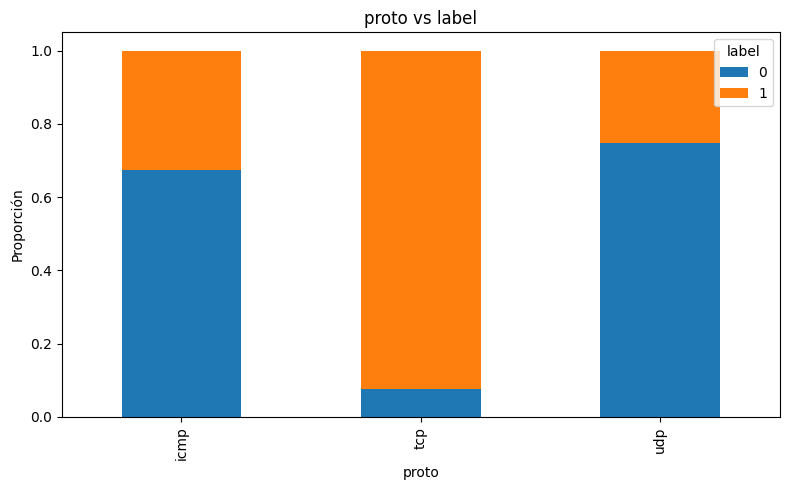

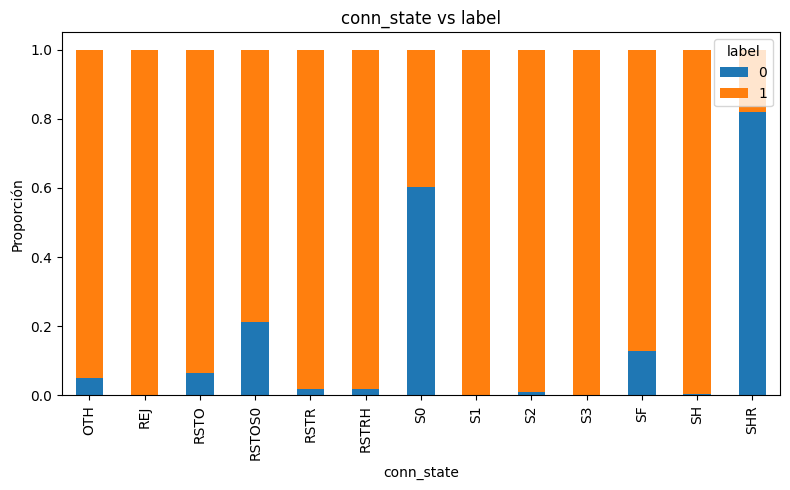

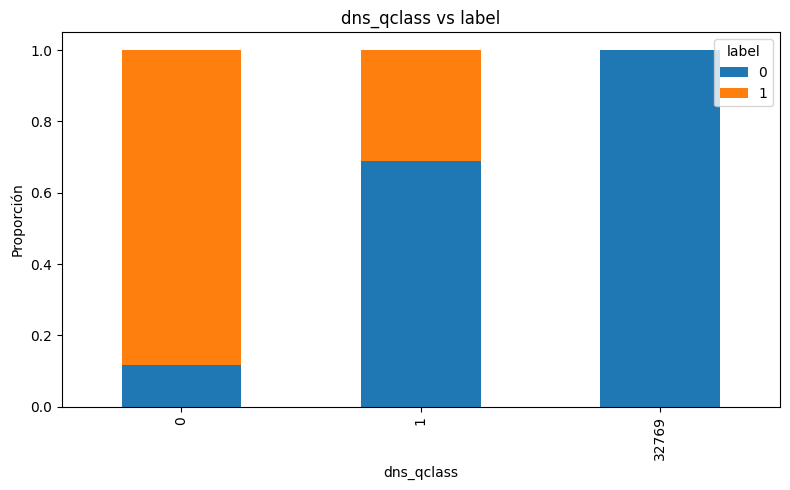

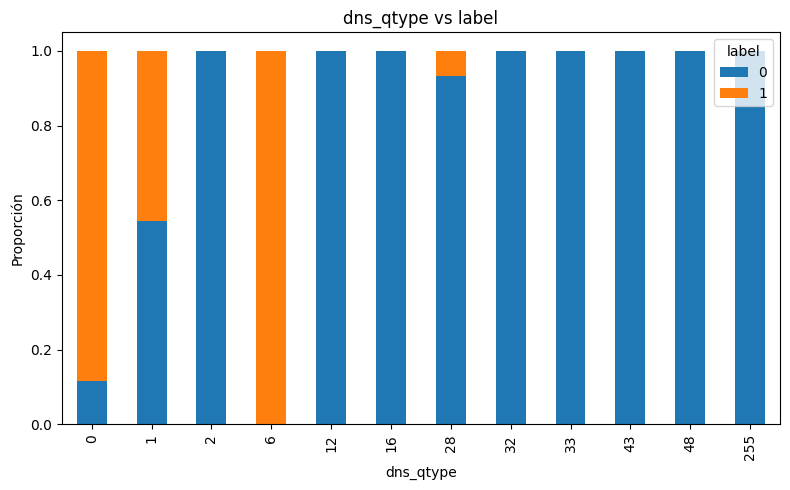

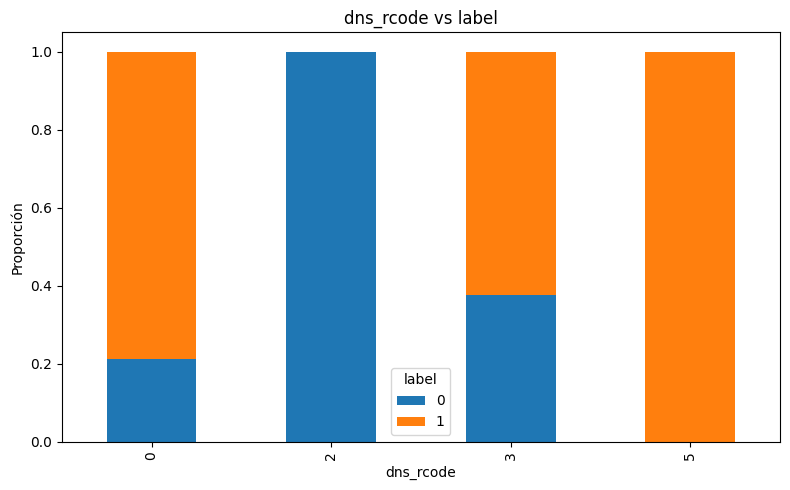

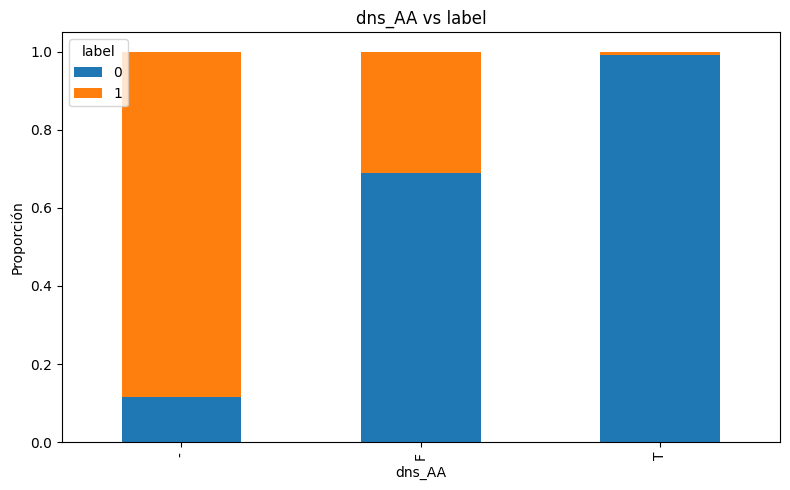

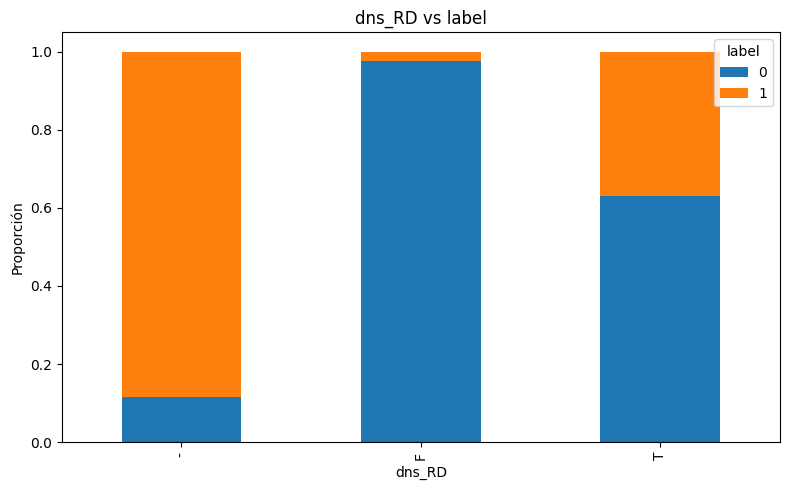

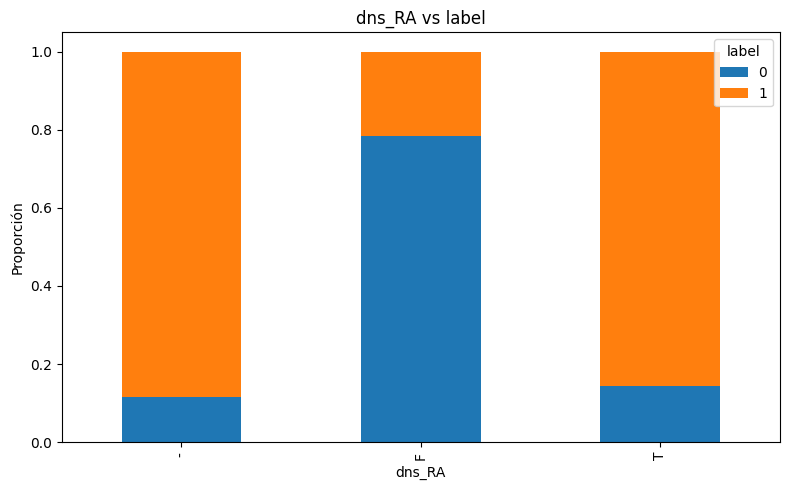

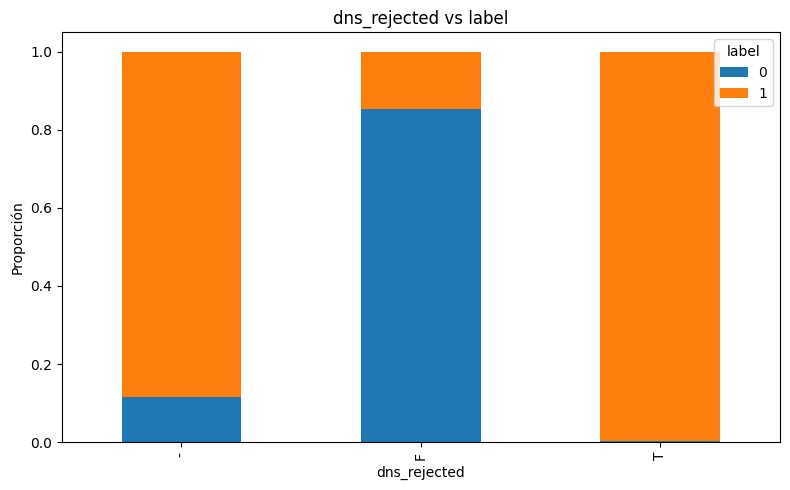

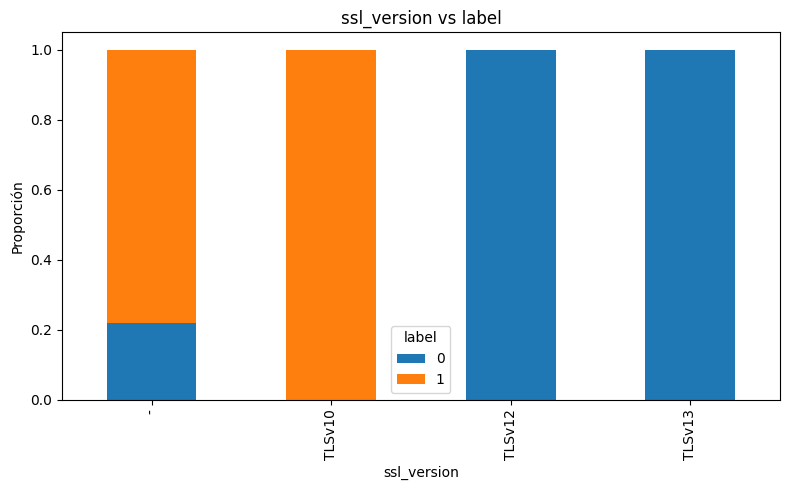

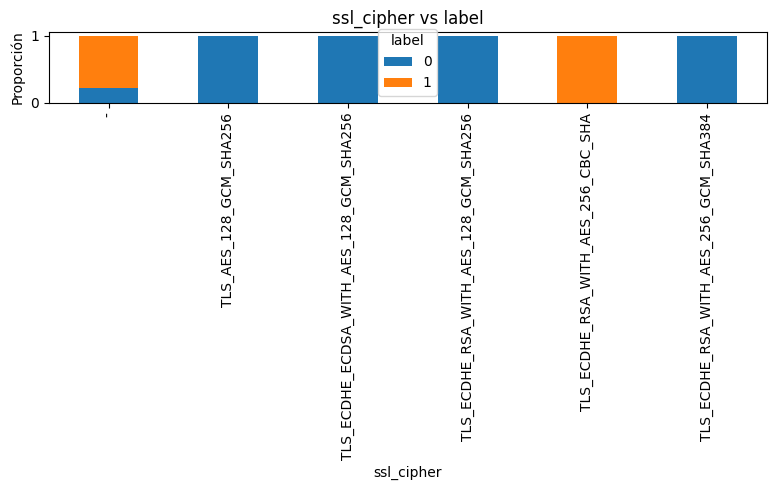

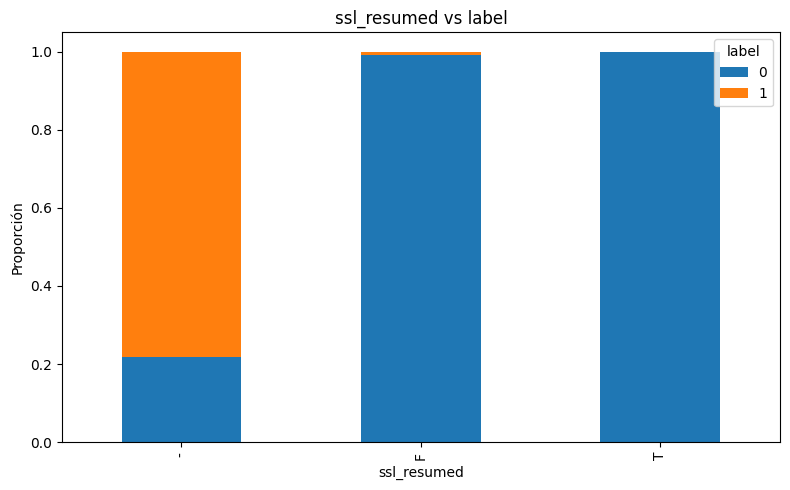

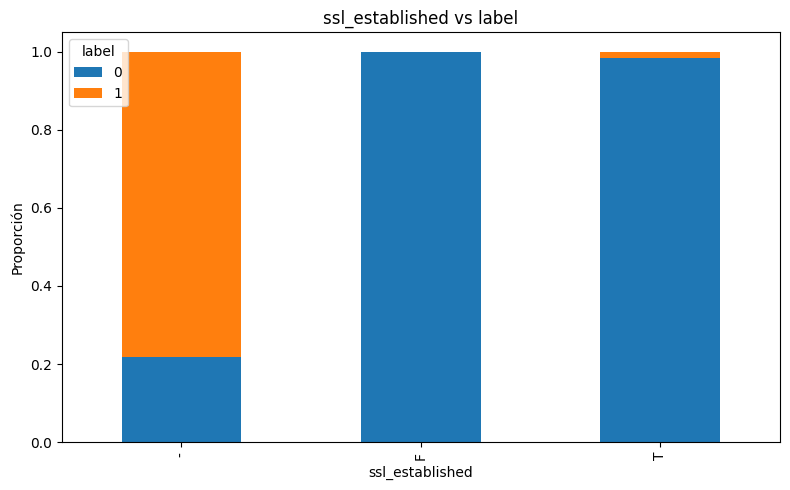

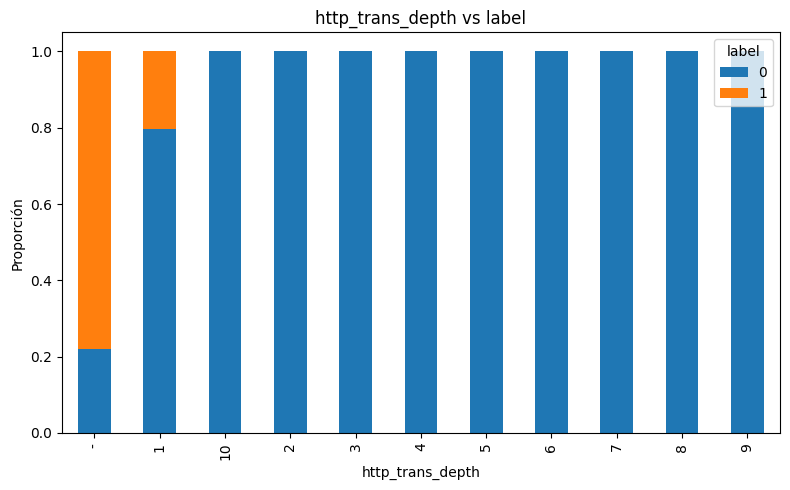

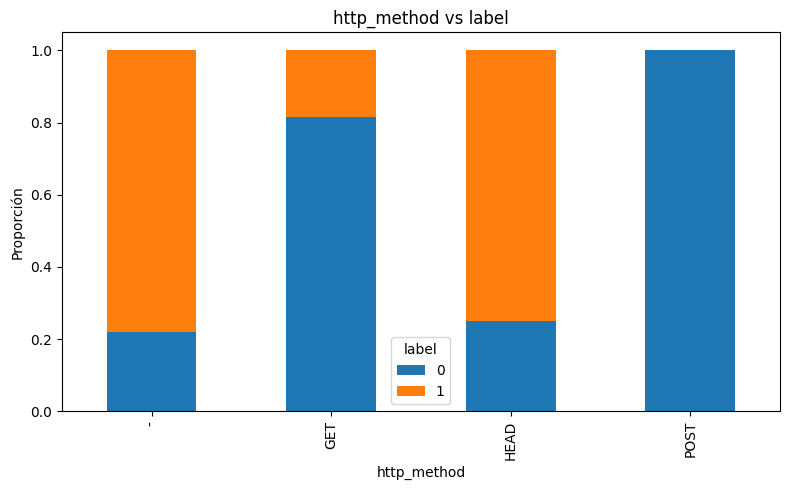

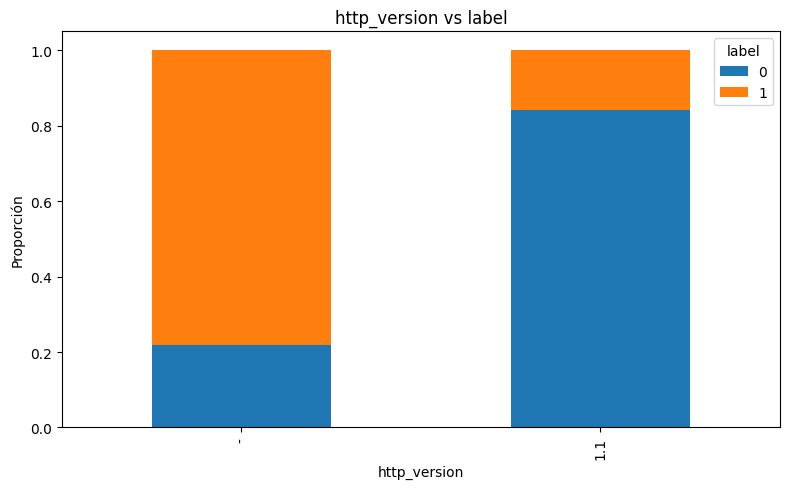

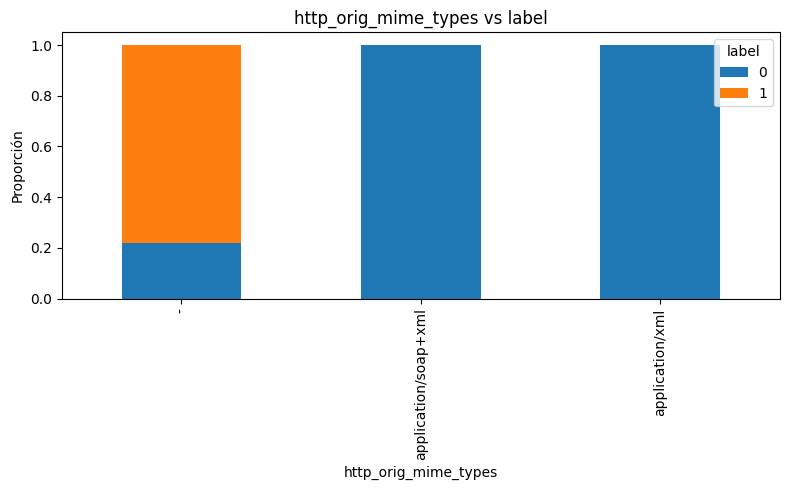

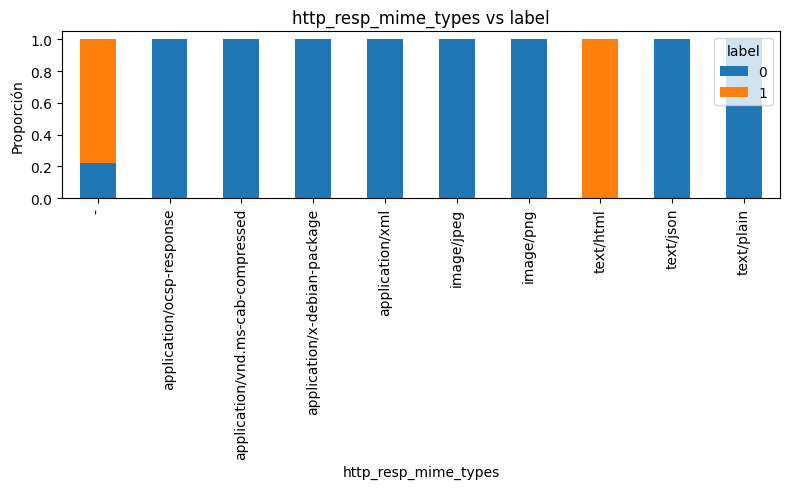

In [22]:
import matplotlib.pyplot as plt

for var in var_categoricas:
    if var != 'label':
        tabla = pd.crosstab(df[var], df['label'], normalize='index')
        tabla.plot(kind='bar', stacked=True, figsize=(8,5))
        plt.title(f'{var} vs label')
        plt.xlabel(var)
        plt.ylabel('Proporción')
        plt.tight_layout()
        plt.show()

## Análisis de variables categóricas

### Variables nominales
- proto, conn_state, http_method, http_version
- ssl_version, ssl_cipher, ssl_resumed, ssl_established
- dns_AA, dns_RD, dns_RA, dns_rejected
- http_status_code, http_orig_mime_types, http_resp_mime_types
- label (variable objetivo)

### Variables ordinales
No se identificaron variables con orden natural.

### Variables eliminadas
- src_port, dst_port: alta cardinalidad (miles de valores)
- dns_query, http_uri, http_user_agent: texto libre
- ssl_subject, ssl_issuer: texto libre
- weird_name, weird_addl, weird_notice: texto de alertas
- service: alta cardinalidad y mayoría '-'

### Procesamiento
- OneHotEncoder para las variables categóricas restantes
- label es la variable objetivo (0=benigno, 1=malicioso)

## Análisis de variables cuantitativas.

In [23]:
num_vars = df.select_dtypes(include='number').columns
print("Variables numéricas:", num_vars.tolist())

Variables numéricas: ['duration', 'src_bytes', 'dst_bytes', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'http_request_body_len', 'http_response_body_len', 'http_status_code']


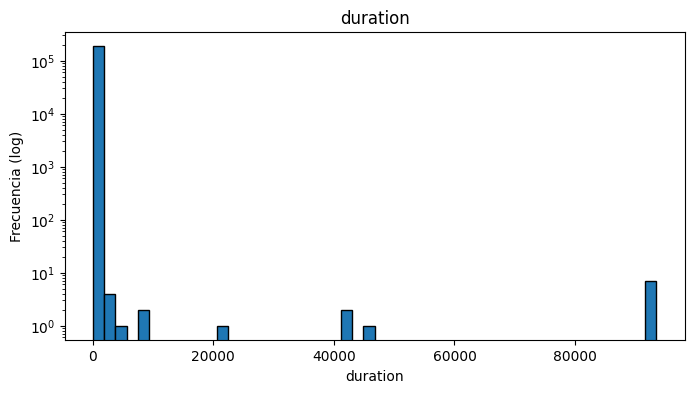

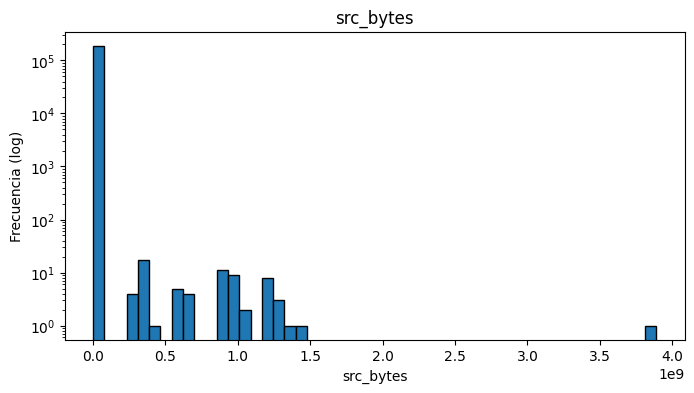

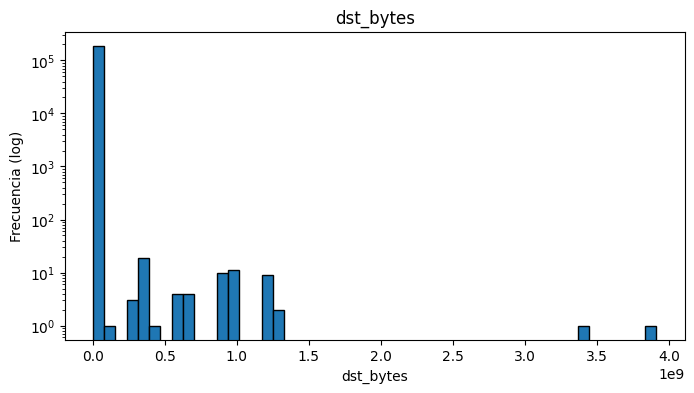

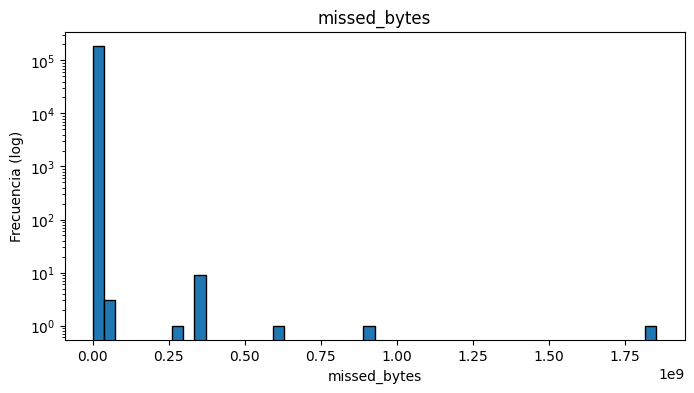

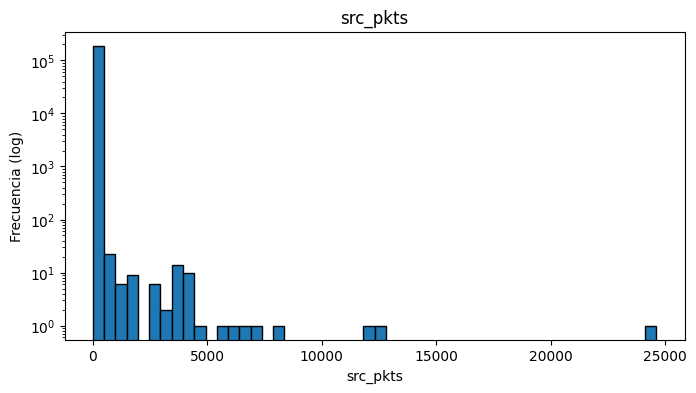

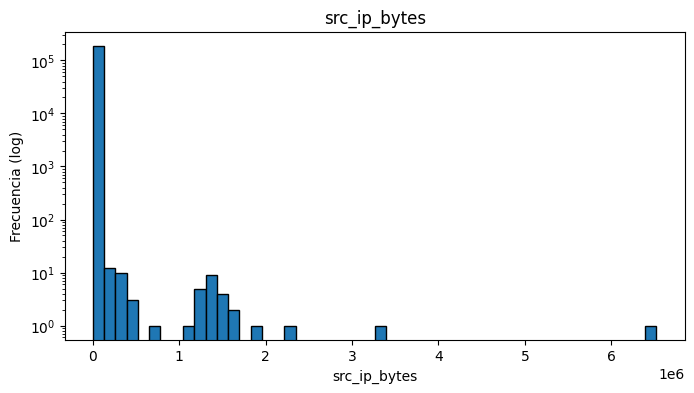

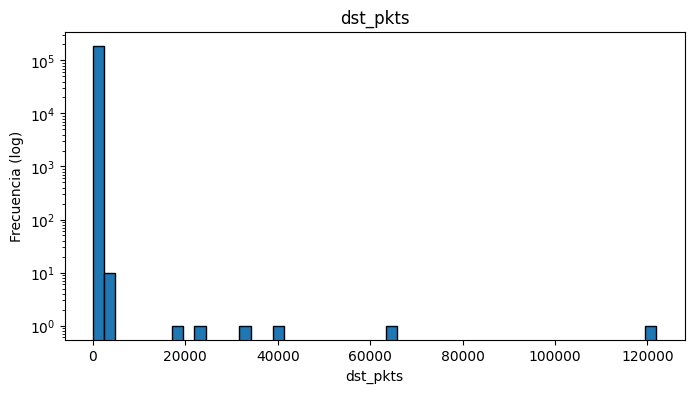

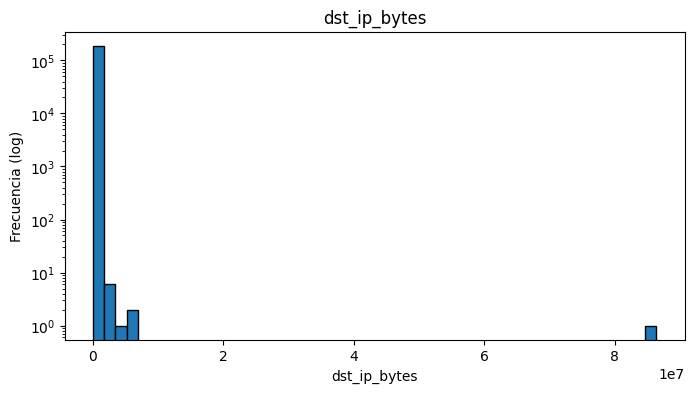

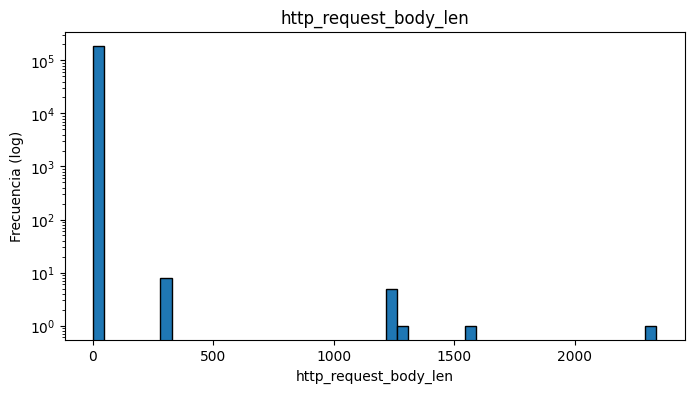

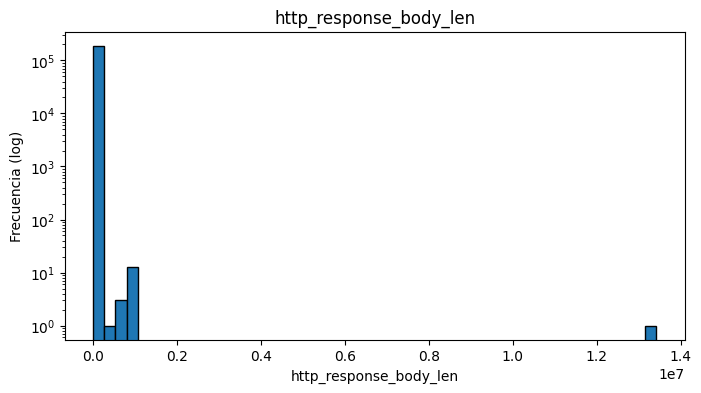

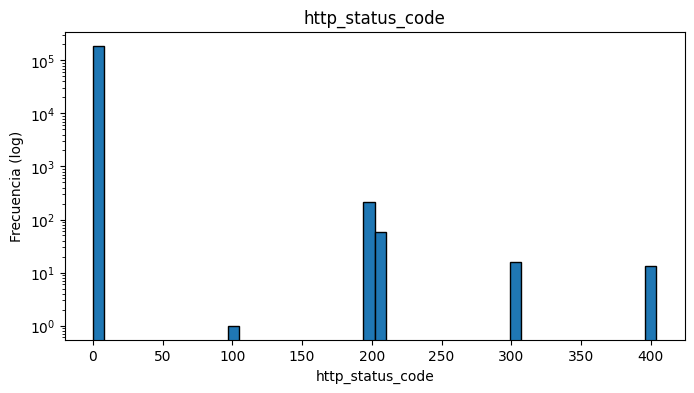

In [ ]:
#para ver forma
import matplotlib.pyplot as plt

num_vars = df.select_dtypes(include='number').columns

for var in num_vars:
    plt.figure(figsize=(8,4))
    plt.hist(df[var], bins=50, edgecolor='black', log=True)
    plt.title(f'{var}')
    plt.xlabel(var)
    plt.ylabel('Frecuencia (log)')
    plt.show()

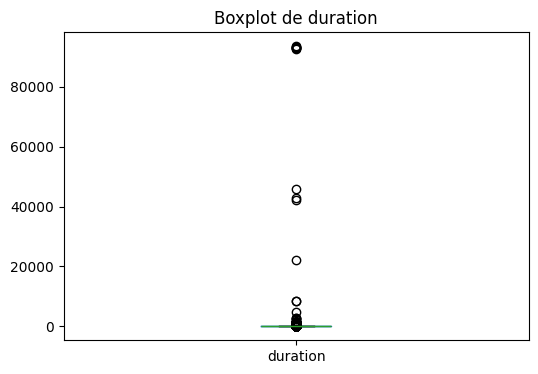

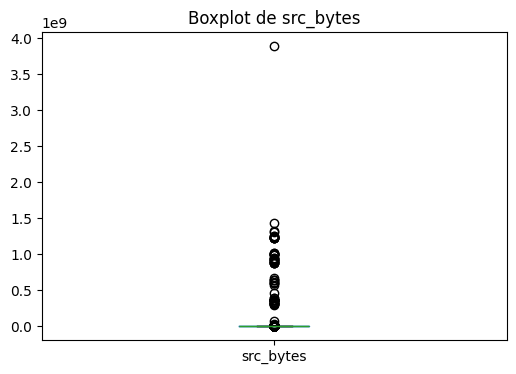

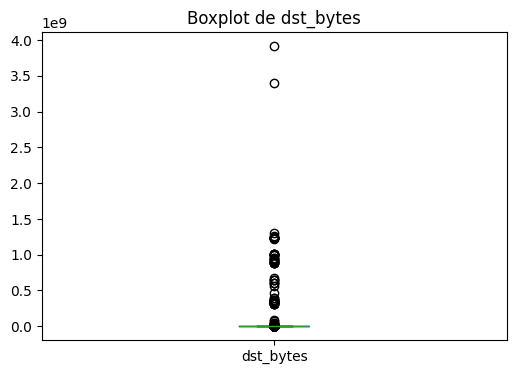

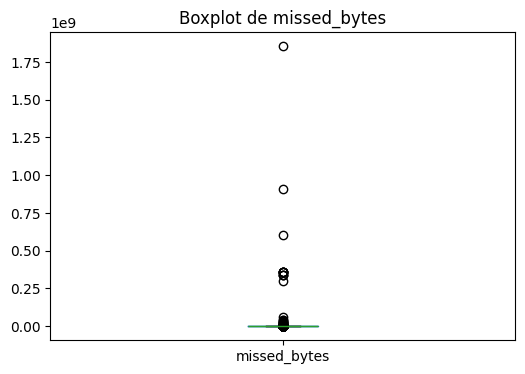

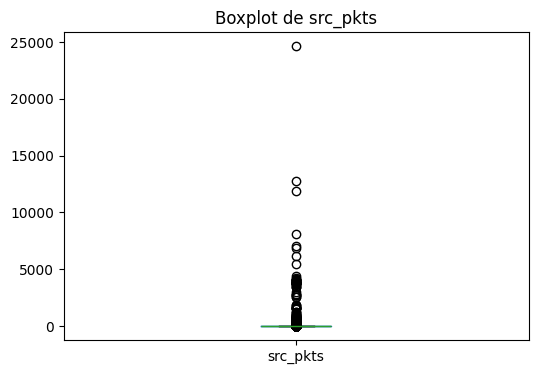

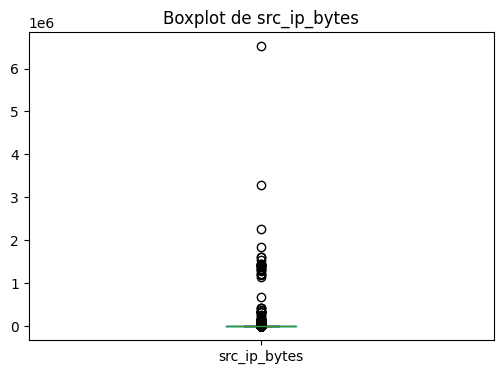

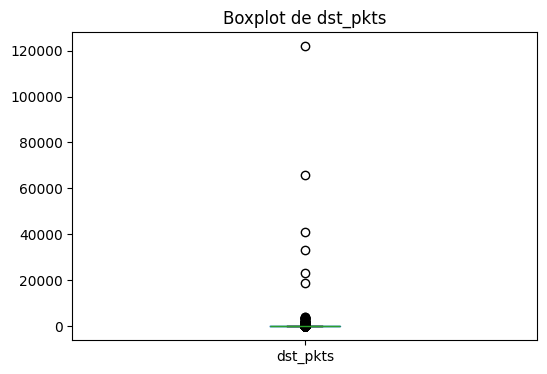

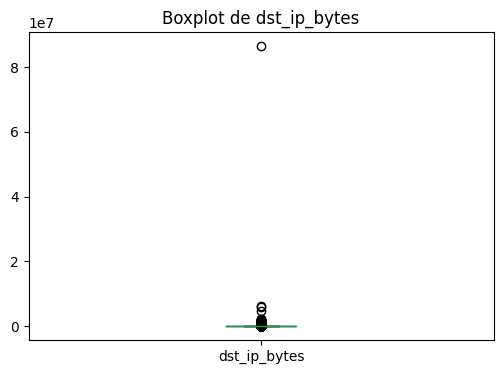

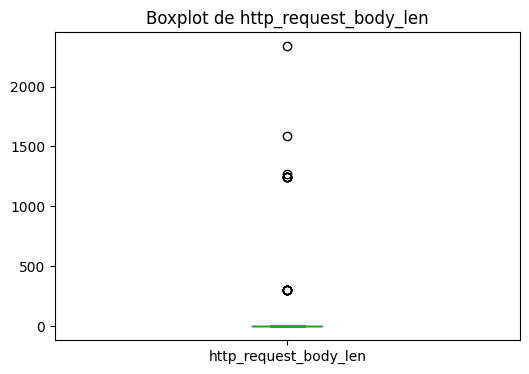

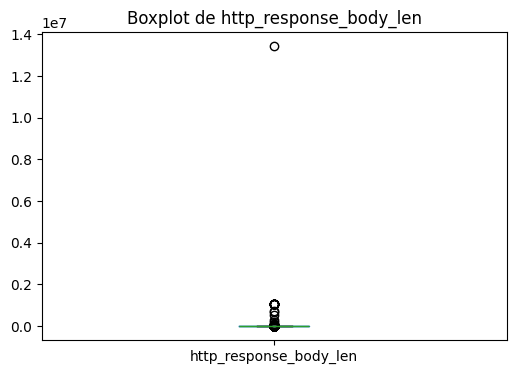

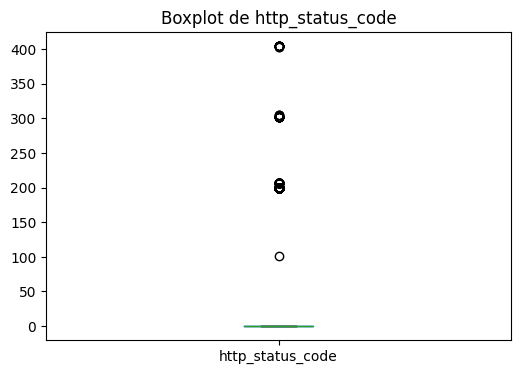

In [27]:
#para identificar outliers claramente
for var in num_vars:
    plt.figure(figsize=(6,4))
    df.boxplot(column=var, grid=False)
    plt.title(f'Boxplot de {var}')
    plt.show()

In [28]:
print("Asimetría (skewness):")
for num in df.select_dtypes(include=['number']).columns:
    print(f"{num}: {df[num].skew():.3f}")

Asimetría (skewness):
duration: 148.114
src_bytes: 96.302
dst_bytes: 108.249
missed_bytes: 240.081
src_pkts: 128.186
src_ip_bytes: 157.394
dst_pkts: 276.577
dst_ip_bytes: 422.448
http_request_body_len: 163.128
http_response_body_len: 387.399
http_status_code: 27.636


In [29]:
print("\nCurtosis (kurtosis):")
for num in df.select_dtypes(include=['number']).columns:
    print(f"{num}: {df[num].kurt():.3f}")


Curtosis (kurtosis):
duration: 22655.897
src_bytes: 14110.834
dst_bytes: 16676.104
missed_bytes: 71371.179
src_pkts: 26021.676
src_ip_bytes: 35331.099
dst_pkts: 87308.845
dst_ip_bytes: 182142.193
http_request_body_len: 29745.816
http_response_body_len: 161156.952
http_status_code: 834.049


In [30]:
# Se eliminan variables sin valor predictivo
eliminar_num = ['src_port', 'dst_port', 'dns_qclass', 'dns_qtype', 'dns_rcode']

print("Variables numéricas a eliminar:", eliminar_num)

Variables numéricas a eliminar: ['src_port', 'dst_port', 'dns_qclass', 'dns_qtype', 'dns_rcode']


In [31]:
df = df.drop(columns=eliminar_num, errors='ignore')
print(f"Dataset después de eliminar: {df.shape}")

Dataset después de eliminar: (190474, 27)


## Análisis de variables cuantitativas

### Distribución
- Ninguna variable tiene distribución normal.
- Todas presentan sesgo positivo o negativo.
- Total Charges es la más cercana a normal (asimetría 0.96).

### Outliers
- Todas las variables presentan valores atípicos.
- Se usarán transformaciones para reducir su impacto.

### Variables eliminadas
- src_port, dst_port, dns_qclass, dns_qtype, dns_rcode: son códigos, no variables continuas.

### Procesamiento
- RobustScaler para variables con outliers.
- StandardScaler para las que se normalicen.

## Procesamiento y entrenamiento del modelo.

In [44]:
df['label'] = df['label'].astype(int)
print("Valores únicos en label:", df['label'].unique())

Valores únicos en label: [1 0]


In [45]:
#Procesamiento y entrenamiento del modelo.

from sklearn.model_selection import train_test_split

y = df['label']
X = df.drop(['label'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1, train_size=0.7)

print(f'Tamaño del conjunto de entrenamiento: {X_train.shape}')
print(f'Tamaño del conjunto de prueba: {X_test.shape}')

Tamaño del conjunto de entrenamiento: (133331, 26)
Tamaño del conjunto de prueba: (57143, 26)


In [46]:
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
    RobustScaler
)

ss = StandardScaler()
rs = RobustScaler()
ohe = OneHotEncoder(sparse_output=False, drop='if_binary', handle_unknown='ignore')

In [47]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers=[
    ('num_prep_ss', ss, ['duration', 'src_bytes', 'dst_bytes', 'src_pkts', 'dst_pkts']),
    ('cod_oh', ohe, ['proto', 'conn_state', 'http_method', 'http_version',
                     'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established',
                     'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected',
                     'http_status_code', 'http_orig_mime_types', 'http_resp_mime_types'])
], remainder='drop')

preprocessor

,transformers,"[('num_prep_ss', ...), ('cod_oh', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [48]:
preprocessor.fit(X_train)
X_train_prep = preprocessor.transform(X_train)
X_test_prep = preprocessor.transform(X_test)

print(f"X_train shape después: {X_train_prep.shape}")
print(f"X_test shape después: {X_test_prep.shape}")

X_train shape después: (133331, 74)
X_test shape después: (57143, 74)


c:\Users\Sara Franco Taborda\Documents\proyectos-datos\Proyecto_analisis\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [52]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=1
)

tree.fit(X_train_prep, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [53]:
print(f'Accuracy en entrenamiento: {tree.score(X_train_prep, y_train):.4f}')
print(f'Accuracy en prueba: {tree.score(X_test_prep, y_test):.4f}')

Accuracy en entrenamiento: 0.9918
Accuracy en prueba: 0.9917


In [54]:
print("Características con las que fue entrenado el modelo:")
for i, nombre in enumerate(preprocessor.get_feature_names_out()):
    print(f"{i+1:3d}. {nombre}")

Características con las que fue entrenado el modelo:
  1. num_prep_ss__duration
  2. num_prep_ss__src_bytes
  3. num_prep_ss__dst_bytes
  4. num_prep_ss__src_pkts
  5. num_prep_ss__dst_pkts
  6. cod_oh__proto_icmp
  7. cod_oh__proto_tcp
  8. cod_oh__proto_udp
  9. cod_oh__conn_state_OTH
 10. cod_oh__conn_state_REJ
 11. cod_oh__conn_state_RSTO
 12. cod_oh__conn_state_RSTOS0
 13. cod_oh__conn_state_RSTR
 14. cod_oh__conn_state_RSTRH
 15. cod_oh__conn_state_S0
 16. cod_oh__conn_state_S1
 17. cod_oh__conn_state_S2
 18. cod_oh__conn_state_S3
 19. cod_oh__conn_state_SF
 20. cod_oh__conn_state_SH
 21. cod_oh__conn_state_SHR
 22. cod_oh__http_method_-
 23. cod_oh__http_method_GET
 24. cod_oh__http_method_HEAD
 25. cod_oh__http_method_POST
 26. cod_oh__http_version_1.1
 27. cod_oh__ssl_version_-
 28. cod_oh__ssl_version_TLSv10
 29. cod_oh__ssl_version_TLSv12
 30. cod_oh__ssl_version_TLSv13
 31. cod_oh__ssl_cipher_-
 32. cod_oh__ssl_cipher_TLS_AES_128_GCM_SHA256
 33. cod_oh__ssl_cipher_TLS_ECDHE


## Estrategia que se decidió aplicar para cada variable

### Cualitativas:
- **proto, conn_state, http_method, http_version, ssl_version, ssl_cipher, ssl_resumed, ssl_established, dns_AA, dns_RD, dns_RA, dns_rejected, http_status_code, http_orig_mime_types, http_resp_mime_types**: son nominales, se usó OneHotEncoder. Como algunas categorías nuevas aparecieron en prueba, se puso handle_unknown='ignore'.
- **label**: es la variable objetivo (0=benigno, 1=malicioso). Se convirtió a entero.

### Cuantitativas:
- **duration, src_bytes, dst_bytes, src_pkts, dst_pkts**: se estandarizaron con StandardScaler porque sus valores están en escalas muy diferentes.